# Expert Evaluation: Blind Grading by Domain Expert

12 university exam questions on nickel superalloy metallurgy, answered by 3 systems and graded blind by a materials science expert on a 1–5 Likert scale (Correctness, Completeness, Relevance).

In [1]:
import json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 130})

ROOT = Path("..")
OUT  = ROOT / "results"

with open(OUT / "expert_scores.json") as f:
    data = json.load(f)

SYSTEMS = {"chatbot": "Chatbot + KG", "llama": "Llama 3.3 70B", "gpt": "GPT-4o"}
SYS_ORDER = ["Chatbot + KG", "GPT-4o", "Llama 3.3 70B"]
CRITERIA = ["correctness", "completeness", "relevance"]
CRIT_LABELS = {"correctness": "Correctness", "completeness": "Completeness", "relevance": "Relevance"}

## Table 1 — Detailed Scores per Question

In [2]:
# One row per (question, system) with all 3 criteria + average
detail_rows = []
for item in data["per_question"]:
    qid = item["question_id"].replace("expert_", "Q")
    for key, label in SYSTEMS.items():
        if key not in item["systems"]:
            continue
        s = item["systems"][key]
        detail_rows.append({
            "Question": qid,
            "System": label,
            "Correctness": s.get("correctness"),
            "Completeness": s.get("completeness"),
            "Relevance": s.get("relevance"),
            "Average": s["avg"],
        })

df_detail = pd.DataFrame(detail_rows)

# Pivot: questions as rows, (System, Criterion) as columns
pivot = df_detail.pivot(index="Question", columns="System",
                        values=["Correctness", "Completeness", "Relevance", "Average"])
pivot = pivot.reindex(columns=pd.MultiIndex.from_product(
    [["Correctness", "Completeness", "Relevance", "Average"], SYS_ORDER]))

(pivot.style
 .format("{:.0f}", na_rep="\u2014", subset=pivot.columns[:9])
 .format("{:.1f}", na_rep="\u2014", subset=pivot.columns[9:])
 .background_gradient(cmap="RdYlGn", vmin=1, vmax=5, subset=pivot.columns[9:])
 .set_caption("Detailed expert scores (1\u20135 Likert scale) per question and system"))

## Table 2 — Aggregate Scores with Statistical Tests

In [3]:
# Aggregate scores
agg_rows = []
for key, label in SYSTEMS.items():
    agg = data["aggregated"][key]
    row = {"System": label}
    for c in CRITERIA:
        row[CRIT_LABELS[c]] = f"{agg[c]['mean']:.2f} \u00b1 {agg[c]['std']:.2f}"
    row["Overall"] = f"{agg['overall']['mean']:.2f} \u00b1 {agg['overall']['std']:.2f}"
    agg_rows.append(row)

df_agg = pd.DataFrame(agg_rows).set_index("System").loc[SYS_ORDER]
display(df_agg.style.set_caption(
    "Aggregate expert scores (mean \u00b1 std, 1\u20135 scale, n=12 questions)"))

# Statistical tests
tests = data["statistical_tests"]
fr = tests["friedman"]
print(f"Friedman test: \u03c7\u00b2={fr['statistic']:.2f}, p={fr['p_value']:.4f}")
print()
for pw in tests["pairwise_wilcoxon"]:
    if "error" not in pw:
        sig = "***" if pw["p_value"] < 0.001 else "**" if pw["p_value"] < 0.01 else "*" if pw["p_value"] < 0.05 else "ns"
        print(f"  {pw['pair']}: W={pw['statistic']:.1f}, p={pw['p_value']:.4f} {sig}")

,Correctness,Completeness,Relevance,Overall
System,,,,
Chatbot + KG,4.08 ± 1.24,3.33 ± 1.07,4.00 ± 0.95,3.81 ± 1.12
GPT-4o,4.92 ± 0.29,4.67 ± 0.89,4.67 ± 0.89,4.75 ± 0.73
Llama 3.3 70B,4.42 ± 1.24,4.58 ± 0.90,4.75 ± 0.62,4.58 ± 0.94


Friedman test: χ²=10.76, p=0.0046

  chatbot vs gpt: W=10.0, p=0.0381 *
  chatbot vs llama: W=1.0, p=0.0156 *
  gpt vs llama: W=5.0, p=0.2812 ns


## Figure — Expert Scores by Criterion

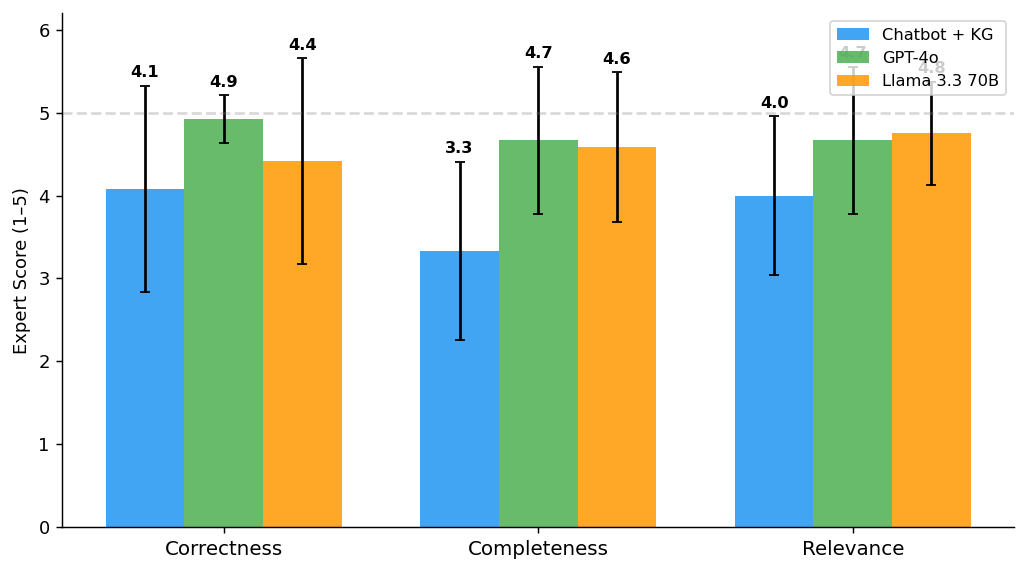

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))

criteria_list = list(CRIT_LABELS.values())
x = np.arange(len(criteria_list))
width = 0.25
colors = {"Chatbot + KG": "#2196F3", "GPT-4o": "#4CAF50", "Llama 3.3 70B": "#FF9800"}

for i, sys in enumerate(SYS_ORDER):
    key = [k for k, v in SYSTEMS.items() if v == sys][0]
    means = [data["aggregated"][key][c]["mean"] for c in CRITERIA]
    stds  = [data["aggregated"][key][c]["std"] for c in CRITERIA]
    bars = ax.bar(x + (i - 1) * width, means, width, yerr=stds,
                  label=sys, color=colors[sys], capsize=3, alpha=0.85)
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(criteria_list, fontsize=11)
ax.set_ylim(0, 6.2)
ax.set_ylabel("Expert Score (1\u20135)")
ax.axhline(y=5, color="grey", linestyle="--", alpha=0.3)
ax.legend(loc="upper right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / "expert_scores_by_criterion.png", dpi=150, bbox_inches="tight")
plt.show()

## Table 3 — Combined Evaluation Summary

All three evaluation tracks side by side.

In [5]:
with open(OUT / "mcq_report.json") as f:
    mcq = json.load(f)
with open(OUT / "ragas_scores.json") as f:
    ragas = json.load(f)

summary_rows = []
for key, label in SYSTEMS.items():
    row = {"System": label}
    s = mcq["systems"][key]
    row["MCQ 1-Hop"] = f"{s['1hop']['accuracy']:.0%}"
    row["MCQ 2-Hop"] = f"{s['2hop']['accuracy']:.0%}"
    if key == "chatbot":
        row["RAGAS Correctness"] = f"{ragas['aggregate']['answer_correctness']:.2f}"
        row["RAGAS Faithfulness"] = f"{ragas['aggregate']['faithfulness']:.2f}"
    else:
        row["RAGAS Correctness"] = "\u2014"
        row["RAGAS Faithfulness"] = "\u2014"
    exp = data["aggregated"][key]
    row["Expert Score"] = f"{exp['overall']['mean']:.2f}/5"
    summary_rows.append(row)

pd.DataFrame(summary_rows).set_index("System").loc[SYS_ORDER].style.set_caption(
    "Combined evaluation: MCQ accuracy, RAGAS quality, and expert judgment")

,MCQ 1-Hop,MCQ 2-Hop,RAGAS Correctness,RAGAS Faithfulness,Expert Score
System,,,,,
Chatbot + KG,100%,79%,0.52,0.74,3.81/5
GPT-4o,33%,42%,—,—,4.75/5
Llama 3.3 70B,35%,43%,—,—,4.58/5
